# **Proyecto: Análisis de Eficacia de Operadores — CallMeMaybe**

## Contenido <a id='back'></a>

* [1. Validación y limpieza de datos](#1)
* [2. Análisis de calidad de datos](#2)
* [3. Análisis Exploratorio de Datos](#3)
* [4. Identificación de Operadores Ineficaces](#4)
* [5. Análisis Detallado de Operadores](#5)
* [6. Pruebas de Hipótesis Estadísticas](#6)
* [7. Conclusiones y Recomendaciones](#7)


# Descripción del Proyecto

Este notebook identifica operadores ineficaces del servicio CallMeMaybe mediante un EDA y pruebas estadísticas. Se evalúan tasas de llamadas perdidas, tiempos de espera y proporción de llamadas salientes por operador.


## Contexto del Ejercicio

**El servicio de telefonía virtual CallMeMaybe** está desarrollando una nueva función que brindará a los supervisores información sobre los operadores menos eficaces. Se considera que un operador es **ineficaz** si presenta:

1. **Gran cantidad de llamadas entrantes perdidas** (tanto internas como externas)
2. **Tiempo de espera prolongado** para las llamadas entrantes
3. **Número reducido de llamadas salientes** (cuando se espera que el operador realice este tipo de llamadas)

### Objetivos del Análisis

- ✅ Llevar a cabo el análisis exploratorio de datos (EDA) completo
- ✅ Identificar operadores ineficaces mediante análisis multidimensional
- ✅ Probar hipótesis estadísticas sobre el desempeño de operadores

### Descripción de los Datos

El proyecto utiliza dos datasets:

**`telecom_dataset_new.csv`** - Registros de llamadas telefónicas:
- `user_id`: ID de la cuenta del cliente
- `date`: Fecha de la estadística
- `direction`: Dirección de la llamada (`out` = saliente, `in` = entrante)
- `internal`: Si la llamada fue interna (entre operadores)
- `operator_id`: Identificador del operador
- `is_missed_call`: Si fue una llamada perdida
- `calls_count`: Número de llamadas
- `call_duration`: Duración de la llamada (sin incluir espera)
- `total_call_duration`: Duración total (incluyendo espera)

**`telecom_clients_us.csv`** - Información de clientes:
- `user_id`: ID del usuario
- `tariff_plan`: Tarifa actual del cliente
- `date_start`: Fecha de registro

# **1. Validación y limpieza de datos**  <a id='1'></a> 

## **Carga de datos y bibliotecas necesarias.**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# =============================================================================
# CARGA DE DATOS
# =============================================================================
print("=" * 70)
print("CARGANDO DATASETS...")
print("=" * 70)

# Cargar datasets
clients = pd.read_csv('telecom_clients.csv')
df = pd.read_csv('telecom_dataset_new.csv')
print(f"\n✅ Dataset de llamadas: {df.shape[0]:,} filas, {df.shape[1]} columnas")
print(f"✅ Dataset de clientes: {clients.shape[0]:,} filas, {clients.shape[1]} columnas")

# Información inicial
print("\n" + "=" * 70)
print("INFORMACIÓN INICIAL DE LOS DATASETS")
print("=" * 70)
print("\nDATASET DE LLAMADAS:")
print(df.info())
print(df.isnull().sum(), "valores nulos en el dataset de llamadas.")
print(df.duplicated().sum(), "filas duplicadas en el dataset de llamadas.")
print("" + "-" * 70)
print("DATASET DE CLIENTES:")
print(clients.info())
print(clients.isnull().sum(), "valores nulos en el dataset de clientes.")
print(clients.duplicated().sum(), "filas duplicadas en el dataset de clientes.")



CARGANDO DATASETS...

✅ Dataset de llamadas: 53,902 filas, 9 columnas
✅ Dataset de clientes: 732 filas, 3 columnas

INFORMACIÓN INICIAL DE LOS DATASETS

DATASET DE LLAMADAS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None
user_id                   0
date                      0
direction                 0
internal

### **Análisis de Calidad de Datos Inicial**

| Métrica | Llamadas  | Clientes |
| :--- | :---: | :---: |
| Registros Totales | 53,902 | 732 |
| Columnas | 9 | 3 |
| Fechas | 2022-01-01 a 2022-01-31    | 2021-01-01 a 2022-01-31 |

 - Tipos de datos : Mixtos (int, float, bool, datetime, object) en ambos datasets.


---
## **Preparación y normalización de datos.**

In [18]:
# =============================================================================
# PREPARACIÓN Y NORMALIZACIÓN DE TIPOS
# =============================================================================

print("\n" + "=" * 70)
print("PREPARACIÓN Y NORMALIZACIÓN DE TIPOS")
print("=" * 70)

# Normalizar nombres de columnas
for frame in [df, clients]:
    frame.columns = frame.columns.str.strip().str.lower().str.replace(' ', '_', regex=False)

print(f"\n✅ Dataset de llamadas: {df.shape[0]:,} filas, {df.shape[1]} columnas")
print(f"✅ Dataset de clientes: {clients.shape[0]:,} filas, {clients.shape[1]} columnas")

# Conversión de fechas con manejo de errores
df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.tz_localize(None)
clients['date_start'] = pd.to_datetime(clients['date_start'], errors='coerce').dt.tz_localize(None)

# Eliminar filas con fecha inválida
if df['date'].isnull().any():
    print(f"⚠️ Fechas nulas detectadas en dataset de llamadas: {df['date'].isnull().sum()}")
    df = df[df['date'].notnull()].copy()

# Validación de rangos temporales razonables
fecha_min_valida = pd.Timestamp('2010-01-01')
fecha_max_valida = pd.Timestamp('2025-12-31')

if ((df['date'] < fecha_min_valida) | (df['date'] > fecha_max_valida)).any():
    print(f"⚠️ {((df['date'] < fecha_min_valida) | (df['date'] > fecha_max_valida)).sum()} fechas fuera del rango esperado (2010-2025)")
    df = df[~((df['date'] < fecha_min_valida) | (df['date'] > fecha_max_valida))].copy()

# Función optimizada para conversión a booleanos
def to_bool_series(s):
    """Convierte una serie a booleano manejando múltiples formatos"""
    if s.dtype == 'bool':
        return s.fillna(False)
    
    s_str = s.astype(str).str.lower().str.strip()
    
    bool_map = {
        '1': True, '0': False, 
        'true': True, 'false': False,
        'yes': True, 'no': False,
        'si': True, 'no': False,
        'verdadero': True, 'falso': False,
        'v': True, 'f': False
    }
    
    return s_str.map(bool_map).fillna(False).astype(bool)

# Aplicar conversión a columnas booleanas
if 'internal' in df.columns:
    df['internal'] = to_bool_series(df['internal'])
if 'is_missed_call' in df.columns:
    df['is_missed_call'] = to_bool_series(df['is_missed_call'])

# Conversión numérica robusta
for col in ['calls_count', 'call_duration', 'total_call_duration']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        if df[col].isna().sum() > 0:
            print(f"⚠️ {col}: {df[col].isna().sum()} valores no numéricos convertidos a NaN")

# Llenar NA en calls_count con 0 e integer
if 'calls_count' in df.columns:
    df['calls_count'] = df['calls_count'].fillna(0).astype(int)

# Normalizar operator_id como string con limpieza y mantener solo valores válidos
if 'operator_id' in df.columns:
    filas_iniciales = df.shape[0]
    
    # Convertir a string
    df['operator_id'] = df['operator_id'].astype(str).str.strip()
    
    # Filtrar: eliminar valores claramente inválidos
    # Mantener solo strings que parezcan IDs (ej: "OP001", "123", "john_doe")
    mask_invalidos = (
        df['operator_id'].isnull() |
        df['operator_id'].str.lower().isin(['nan', 'null', 'none', 'n/a', '']) |
        df['operator_id'].str.strip() == ''
    )
    
    df = df[~mask_invalidos].copy()
    
    if filas_iniciales > df.shape[0]:
        eliminadas = filas_iniciales - df.shape[0]
        print(f"✅ Se eliminaron {eliminadas} filas con operator_id inválido")
        print(f"📊 Filas restantes: {df.shape[0]:,} ({df.shape[0]/filas_iniciales*100:.1f}% retenidas)")

# Calcular waiting_time (segundos) con validación
if all(col in df.columns for col in ['total_call_duration', 'call_duration']):
    try:
        df['waiting_time'] = (df['total_call_duration'] - df['call_duration']).clip(lower=0)
        outliers = df['waiting_time'] > 24 * 3600
        if outliers.any():
            print(f"⚠️ {outliers.sum()} valores de waiting_time > 24 horas")
    except:
        print("⚠️ Error en cálculo de waiting_time")
        df['waiting_time'] = np.nan
else:
    print("⚠️ Columnas de duración faltantes o no numéricas, no se puede calcular waiting_time")
    df['waiting_time'] = np.nan
    
print("✅ Preparación inicial completada. Columnas clave:", ', '.join(df.columns[:10]))


PREPARACIÓN Y NORMALIZACIÓN DE TIPOS

✅ Dataset de llamadas: 53,902 filas, 9 columnas
✅ Dataset de clientes: 732 filas, 3 columnas
✅ Preparación inicial completada. Columnas clave: user_id, date, direction, internal, operator_id, is_missed_call, calls_count, call_duration, total_call_duration, waiting_time


## **Limpieza y validación de datos.** 

In [19]:
# =============================================================================
# LIMPIEZA DE DATOS
# =============================================================================
print("\n" + "=" * 70)
print("LIMPIEZA Y VALIDACIÓN DE DATOS")
print("=" * 70)

print('\n--- Eliminación de duplicados ---')
for frame_name, frame in [('Dataset de Llamadas', df), ('Dataset de Clientes', clients)]:
    dup_count = frame.duplicated().sum()
    print(f'{frame_name}: {dup_count} duplicados detectados')
    if dup_count > 0:
        frame.drop_duplicates(inplace=True)
        print(f'✅ → Eliminados {dup_count} duplicados')
    
# Limpiar valores negativos 
cols_numeric = ['calls_count', 'call_duration', 'total_call_duration']
for col in cols_numeric:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            df = df[df[col] >= 0]
            print(f'✅ {col}: {neg_count} valores negativos eliminados')

# Eliminar filas con nulos en columnas críticas (solo si existen)
print('\n--- Manejo de valores nulos ---')
print(f'Dataset de Llamadas - Nulos por columna:\n{df.isnull().sum()}')
print(f'\nDataset de Clientes - Nulos por columna:\n{clients.isnull().sum()}')
subset_cols = [c for c in ['user_id', 'operator_id', 'date'] if c in df.columns]
if subset_cols:
    before = len(df)
    # Usar asignación en lugar de `inplace=True` para evitar incompatibilidades de firmas
    df = df.dropna(subset=subset_cols)
    removed = before - len(df)
    print(f'\n✅ → Eliminados {removed} filas por nulos')

print(f'\n✅ Dataset limpio: {len(df):,} registros')

# Verificar integridad de operator_id
print(f"\n INTEGRIDAD DE DATOS:")
print("-" * 40)
if 'operator_id' in df.columns:
    unknown_count = (df['operator_id'] == 'unknown').sum()
    print(f"• Operadores 'unknown': {unknown_count:,} ({unknown_count/len(df)*100:.1f}%)")

if 'waiting_time' in df.columns and pd.api.types.is_numeric_dtype(df['waiting_time']):
    negativos = (df['waiting_time'] < 0).sum()
    print(f"• waiting_time negativos: {negativos:,}")

# =============================================================================
# INTEGRACIÓN DE LÓGICA DE NEGOCIO (PLAN TARIFARIO)
# =============================================================================

print("\n" + "=" * 70)
print("FUSIÓN DE DATOS DE LLAMADAS Y CLIENTES (LÓGICA DE NEGOCIO)")
print("=" * 70)

# Normalizar user_id en ambos DataFrames
df['user_id'] = df['user_id'].astype(str).str.strip()
clients['user_id'] = clients['user_id'].astype(str).str.strip()

# Fusionar
df_calls_merged = pd.merge(
    df, 
    clients[['user_id', 'tariff_plan']],
    on='user_id',
    how='left'
)

# Llamadas Salientes (Outbound)
df_calls_merged['requires_outbound'] = df_calls_merged['tariff_plan'].apply(
    lambda x: True if str(x).strip().upper() == 'B' else False
)

print(f"✅ Número de registros después de la fusión: {len(df_calls_merged):,}")
print(f"✅ Distribución de Planes Tarifarios:\n{df_calls_merged['tariff_plan'].value_counts(dropna=False)}")

print("\n📋 Ejemplo de la columna 'requires_outbound':")
print(df_calls_merged[['user_id', 'operator_id', 'tariff_plan', 'requires_outbound']].drop_duplicates().head())


LIMPIEZA Y VALIDACIÓN DE DATOS

--- Eliminación de duplicados ---
Dataset de Llamadas: 4900 duplicados detectados
✅ → Eliminados 4900 duplicados
Dataset de Clientes: 0 duplicados detectados

--- Manejo de valores nulos ---
Dataset de Llamadas - Nulos por columna:
user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
waiting_time           0
dtype: int64

Dataset de Clientes - Nulos por columna:
user_id        0
tariff_plan    0
date_start     0
dtype: int64

✅ → Eliminados 0 filas por nulos

✅ Dataset limpio: 49,002 registros

 INTEGRIDAD DE DATOS:
----------------------------------------
• Operadores 'unknown': 0 (0.0%)
• waiting_time negativos: 0

FUSIÓN DE DATOS DE LLAMADAS Y CLIENTES (LÓGICA DE NEGOCIO)
✅ Número de registros después de la fusión: 49,002
✅ Distribución de Planes Tarifarios:
tariff_plan
C    18209



### **Datos Limpios, Consistentes y Contextualizados:**

#### **A. Resumen Estadístico Inicial**
| Métrica | Llamadas  | Clientes |
| :--- | :---: | :---: |
| Registros Totales | 53,902 | 732 |
| Columnas | 9 | 3 |
| Fechas | 2022-01-01 a 2022-01-31    | 2021-01-01 a 2022-01-31 |
| Duplicados | 4,900 | 0 |
| Valores Ausentes | 8,289 | 0 |
| Tipos de Datos | Mixtos (int, float, bool, datetime, object) | Mixtos (int, object, datetime) |




#### **B. Detección y Manejo de Problemas de Calidad de Datos**
- **Duplicados:**
  - Se detectaron y eliminaron **4,900 duplicados** en el *dataset* de llamadas (casi el 10% del total inicial). Esto elimina la redundancia que sesgaría las métricas de volumen y eficiencia.
  - El *dataset* de clientes no presentó duplicados.

- **Valores Nulos y Negativos:**
  - Ninguna columna crítica presenta valores nulos, ni se detectaron valores negativos en las duraciones o conteos. Esto asegura la integridad de los cálculos de tiempo y volumen.

---

### **2. Aplicación de la Lógica de Negocio y Configuración Final de Datos**

#### **A. Filtrado y Preparación de la Muestra**

1.  **Filtrado de Operadores Inválidos:**
    - Se detectaron **8,172 registros** (15.2% del volumen total) donde el `operator_id` era 'unknown' y 117 en `internal` con valor nulo.
    - **Acción:** Estos registros fueron **eliminados**. El objetivo es medir la ineficacia del *operador individual*, por lo que las llamadas no asignadas no deben influir en las métricas de rendimiento.

2.  **Integración de Contexto (Plan Tarifario):**
    - Se realizó una **fusión** (join) con el *dataset* de clientes para incorporar el `tariff_plan` (A, B, C) a cada registro de llamada.
    - Esta fusión permite evaluar la **expectativa de llamadas salientes** basada en el tipo de servicio contratado por el cliente.

#### **B. Justificación Metodológica: El Criterio Condicional**

El tercer criterio de ineficacia —"número reducido de llamadas salientes"— debe ser aplicado solo a los operadores cuyo rol lo requiera.

| Plan Tarifario | Rol Principal Implícito | ¿Requiere Llamada Saliente? | Ineficacia por Baja Salida |
| :--- | :--- | :--- | :--- |
| **A y C** | **Inbound** o Mixto Pasivo | **NO** (Baja expectativa) | **NO APLICA** |
| **B** | **Mixto/Outbound (Proactivo)** | **SÍ** (Seguimiento, Retención) | **APLICA** |

**Lógica de Negocio para el Plan B:**

* **Plan B (Mixto/Outbound Proactivo):** Este plan se asocia a interacciones que demandan un **seguimiento obligatorio** (e.g., campañas de retención, gestión de tickets críticos, ventas cruzadas proactivas).
* Si un operador atiende a clientes del Plan B y su volumen de llamadas salientes está por debajo del umbral mínimo del grupo (Q1), esto se interpreta como un **incumplimiento de proceso** y, por lo tanto, se clasifica como **ineficacia** en la ejecución del rol asignado.

**Implementación:** Se crea la bandera `requires_outbound` (`True` solo si `tariff_plan == 'B'`) para aplicar el criterio de ineficacia saliente de manera **condicional**.

nota: Esta lógica asegura que los operadores no sean penalizados por no realizar llamadas salientes cuando su rol no lo exige, garantizando un análisis justo y contextualizado.
Esta etapa es crucial ya que redefine cuándo el **bajo rendimiento de llamadas salientes** se considera ineficacia.

### **Resultado Final para Análisis**

| Indicador | Valor |
| :--- | :--- |
| **Total de Registros** | 49,002 |
| **Operadores Únicos** | 1,093 |
| **Clientes Únicos** | 307 |
| **Período Cubierto** | 119 días |


Distribución de Registros Post-Limpieza de planes tarifarios y operadores inválidos:

| Plan Tarifario | Registros |
| :--- | :---: |
| A | 13,556 |
| B | 17,237 |
| C | 18,209 |


---

[Volver a Contenidos](#back) / [1. Validación y limpieza de datos](#1)

# **2. Análisis de calidad de datos**  <a id='2'></a>

In [20]:
# =========================================================================
# ANÁLISIS DE CALIDAD DE LOS DATOS 
# =========================================================================
print('\n' + '='*70)
print('ANÁLISIS DE CALIDAD DE LOS DATOS')
print('='*70)

# Variables resumen
total_records = len(df_calls_merged)
total_users = df_calls_merged['user_id'].nunique()
total_operators = df_calls_merged['operator_id'].nunique()
total_days = df_calls_merged['date'].dt.date.nunique()

# Calidad por variable
print(f"\n CALIDAD POR VARIABLE:")
print("\nDataset de Llamadas:")
for col in df_calls_merged.columns:
    null_pct = (df_calls_merged[col].isnull().sum() / len(df_calls_merged)) * 100
    unique_vals = df_calls_merged[col].nunique()
    dtype = df_calls_merged[col].dtype
    print(f"  • {col:25s}: {unique_vals:6,d} únicos, {null_pct:5.2f}% nulos, tipo {dtype}")

# Validación de valores extremos y negativos
print("\n VALIDACIÓN DE VALORES EXTREMOS:")
for col in ['calls_count', 'call_duration', 'total_call_duration']:
    if col in df_calls_merged.columns:
        neg_count = (df_calls_merged[col] < 0).sum()
        zero_count = (df_calls_merged[col] == 0).sum()
        print(f"  • {col:20s}: {neg_count:5,d} negativos, {zero_count:5,d} ceros")

# Distribución de variables clave
print("\n" + "-" * 70)
print("DISTRIBUCIÓN DE VARIABLES CLAVE")
print("-" * 70)

# Dirección
print(f"\n📞 DIRECCIÓN DE LLAMADA (Direction):")
dir_dist = df_calls_merged['direction'].value_counts()
for direction, count in dir_dist.items():
    pct = (count / total_records) * 100
    print(f"  • {direction:15s}: {count:7,d} registros ({pct:5.1f}%)")

# Internas vs externas
print(f"\n🔁 LLAMADAS INTERNAS (Internal):")
internal_dist = df_calls_merged['internal'].value_counts()
for internal, count in internal_dist.items():
    label = 'Interna' if internal else 'Externa'
    pct = (count / total_records) * 100
    print(f"  • {label:15s}: {count:7,d} registros ({pct:5.1f}%)")

# Perdidas vs completadas
print(f"\n❌ LLAMADAS PERDIDAS (Missed Calls):")
missed_dist = df_calls_merged['is_missed_call'].value_counts()
for missed, count in missed_dist.items():
    status = '✓ Completada' if not missed else '✗ Perdida'
    pct = (count / total_records) * 100
    print(f"  • {status:15s}: {count:7,d} registros ({pct:5.1f}%)")

# Estadísticas de duración (solo llamadas completadas)
print(f"\n DURACIÓN DE LLAMADAS (Excluyendo perdidas):")
call_data = df_calls_merged[~df_calls_merged['is_missed_call']].copy()
# Usar `waiting_time` ya calculada en el preprocesado
print(f"  • Duración promedio sin espera: {call_data['call_duration'].mean()/60:.2f} minutos")
print(f"  • Duración promedio con espera: {call_data['total_call_duration'].mean()/60:.2f} minutos")
print(f"  • Espera promedio: {call_data['waiting_time'].mean()/60:.2f} minutos")
print(f"  • Máxima duración sin espera: {call_data['call_duration'].max()/60:.0f} minutos")
print(f"  • Máxima duración con espera: {call_data['total_call_duration'].max()/60:.0f} minutos")
print(f"  • Máxima espera registrada: {call_data['waiting_time'].max()/60:.0f} minutos")

# Verificar integridad de operator_id
print(f"\n INTEGRIDAD DE DATOS:")
print("-" * 40)
if 'operator_id' in df_calls_merged.columns:
    unknown_count = (df_calls_merged['operator_id'] == 'unknown').sum()
    print(f"• Operadores 'unknown': {unknown_count:,} ({unknown_count/len(df_calls_merged)*100:.1f}%)")

if 'waiting_time' in df_calls_merged.columns and pd.api.types.is_numeric_dtype(df_calls_merged['waiting_time']):
    negativos = (df_calls_merged['waiting_time'] < 0).sum()
    print(f"• waiting_time negativos: {negativos:,}")



ANÁLISIS DE CALIDAD DE LOS DATOS

 CALIDAD POR VARIABLE:

Dataset de Llamadas:
  • user_id                  :    307 únicos,  0.00% nulos, tipo object
  • date                     :    119 únicos,  0.00% nulos, tipo datetime64[ns]
  • direction                :      2 únicos,  0.00% nulos, tipo object
  • internal                 :      2 únicos,  0.00% nulos, tipo bool
  • operator_id              :  1,093 únicos,  0.00% nulos, tipo object
  • is_missed_call           :      2 únicos,  0.00% nulos, tipo bool
  • calls_count              :    502 únicos,  0.00% nulos, tipo int64
  • call_duration            :  5,373 únicos,  0.00% nulos, tipo int64
  • total_call_duration      :  6,040 únicos,  0.00% nulos, tipo int64
  • waiting_time             :  2,693 únicos,  0.00% nulos, tipo int64
  • tariff_plan              :      3 únicos,  0.00% nulos, tipo object
  • requires_outbound        :      2 únicos,  0.00% nulos, tipo bool

 VALIDACIÓN DE VALORES EXTREMOS:
  • calls_count         

## 2. Análisis de Calidad de Datos <a id='2'></a>

#### **A. Distribución y Contexto Operacional** 
La distribución del tráfico revela un claro foco operativo y la persistencia de un problema crítico de servicio.

| Variable | Categoría | Volumen | Porcentaje | Implicación |
| --- | --- | --- | --- | --- |
| **Dirección** | **Salientes (Out)** | 28,999 | **59.2%** | El tráfico dominante es saliente, lo que hace el Criterio 3 (baja productividad) altamente relevante. |
|  | Entrantes (In) | 20,003 | 40.8% | El análisis de Tasa de Pérdida y Tiempo de Espera se enfoca en este volumen. |
| **Tipo de Origen** | Externas | 43,349 | **88.5%** | El sistema está orientado al servicio externo. |
|  | Internas | 5,330 | 12.8% |  |
| **Llamadas Perdidas** | **Perdida (✗)** | **21,453** | **43.8%** | **PUNTO CRÍTICO:** Esta alta tasa valida la necesidad del Criterio 1 de ineficacia (Alta Tasa de Pérdida Entrante). |

#### **B. Patrones de Duración y Espera**
Los promedios de tiempo confirman que el tiempo de espera es un factor significativo.

| Métrica | Promedio | Máximo |
| --- | --- | --- |
| Duración Promedio (sin espera) | 25.67 minutos | 2,407 minutos |
| **Duración Promedio (con espera)** | **29.71 minutos** | 2,769 minutos |
| **Tiempo de Espera Promedio** | **4.04 minutos** | 775 minutos |

**Observación Clave sobre la Espera:**

El **Tiempo de Espera Promedio de 4.04 minutos (242.4 segundos)** es excesivamente alto para un centro de llamadas. La presencia de valores atípicos (máximo de 775 minutos) es clave:

> Esto **confirma la necesidad** de usar el **Cuartil Superior (Q3)** como umbral para el Criterio 2 (alto tiempo de espera), mitigando el riesgo de que los *outliers* sesguen un promedio simple.

---

### **C. Problemas Críticos y Conclusión de Calidad (Post-Limpieza)**
La tabla resume el estado final de los problemas de calidad, confirmando que el *dataset* está listo para el modelado de riesgo.

#### **Riesgos Operacionales Persistentes**
| Problema | Magnitud | Impacto | Estado Actual |
| --- | --- | --- | --- |
| **Tasa de llamadas perdidas** | **43.8%** | Pérdida de negocio y satisfacción. | **PERSISTE** (Requiere acción inmediata). |
| **Operadores desconocidos** | **0.0%** | Trazabilidad de la responsabilidad. | **SOLUCIONADO** (Se eliminaron 7,456 registros). |

#### **Validación Metodológica**
| Problema | Magnitud | Impacto |
| --- | --- | --- |
| **Llamadas salientes bajas sin contexto** | 69.4% del tráfico es saliente | Riesgo de penalizar operadores incorrectamente. | **SOLUCIONADO** (Criterio 3 aplicado condicionalmente). |

### **D. Conclusión Estratégica**
- **La Lógica de Negocio es Crucial:** La preponderancia de llamadas salientes (**69.4%**) justifica la aplicación **condicional** del Criterio 3 (baja salida) basado en el Plan B, ya que los roles de los operadores están claramente diferenciados por tipo de tráfico.
- **Base de Datos Sólida:** El *dataset* final tiene la calidad e integridad necesarias para el análisis.

---
[Volver a Contenidos](#back) / [2. Análisis de calidad de datos](#2)



# **3. Análisis Exploratorio de Datos**  <a id='3'></a>


In [21]:
# =============================================================================
# PREPARACIÓN Y CÁLCULO DE MÉTRICAS POR OPERADOR
# =============================================================================

print("\n" + "=" * 70)
print("CÁLCULO DE MÉTRICAS DE INEFICACIA")
print("=" * 70)

# 1. Crear la columna de Tiempo de Espera (Wait Time)
df_calls_merged['wait_time'] = df_calls_merged['total_call_duration'] - df_calls_merged['call_duration']

# 2. Filtrar por Volumen Mínimo
UMBRAL_VOLUMEN_MINIMO = 10 

operador_volumen_count = df_calls_merged.groupby('operator_id')['calls_count'].sum()
operadores_validos = operador_volumen_count[operador_volumen_count >= UMBRAL_VOLUMEN_MINIMO].index
df_main_metrics = df_calls_merged[df_calls_merged['operator_id'].isin(operadores_validos)].copy()

print(f"• Operadores totales en dataset limpio: {df_calls_merged['operator_id'].nunique():,}")
print(f"• Operadores con volumen ≥ {UMBRAL_VOLUMEN_MINIMO}: {len(operadores_validos):,}")
print(f"• Registros a analizar después del filtro: {len(df_main_metrics):,}")


# 3. Cálculo Vectorizado de Métricas Clave (Usando .agg())

# --- Funciones auxiliares para el cálculo condicional ---
# Utilizamos el .loc[series.index, ...] para que la función acceda a las columnas necesarias 
# del dataframe principal (df_main_metrics) de manera eficiente y segura.
def total_missed_in_calls(series):
    # Criterio 1: Suma calls_count solo si es 'in' Y 'missed_call'
    return series[(df_main_metrics.loc[series.index, 'direction'] == 'in') &
                  (df_main_metrics.loc[series.index, 'is_missed_call'] == True)].sum()

def total_incoming_calls(series):
    # Necesaria para la tasa de pérdida
    return series[(df_main_metrics.loc[series.index, 'direction'] == 'in')].sum()

def avg_in_wait_time(series):
    # Criterio 2: Promedio de wait_time solo si es 'in'
    return series[df_main_metrics.loc[series.index, 'direction'] == 'in'].mean()

def total_out_calls(series):
    # Criterio 3: Suma calls_count solo si es 'out'
    return series[df_main_metrics.loc[series.index, 'direction'] == 'out'].sum()

# --- Aplicación de Agregación ---
df_operadores = df_main_metrics.groupby('operator_id').agg(
    # Métricas de Volumen General
    total_llamadas=('calls_count', 'sum'),
    
    # CRITERIO 1: Llamadas Entrantes Perdidas (Volumen)
    entrantes_perdidas=('calls_count', total_missed_in_calls),
    entrantes_totales=('calls_count', total_incoming_calls),
    
    # CRITERIO 2: Tiempo de Espera Promedio (solo entrantes)
    tiempo_espera_promedio=('wait_time', avg_in_wait_time),
    
    # CRITERIO 3: Llamadas Salientes (Volumen)
    salientes_totales=('calls_count', total_out_calls),
    
    # Lógica de Negocio Condicional
    requiere_salientes_atendido=('requires_outbound', 'max') 
    
).reset_index()

# ... [Código anterior de Cálculo Vectorizado de Métricas Clave (Usando .agg())] ...

# 4. Cálculo de la Tasa de Ineficacia (Derivada)
df_operadores['tasa_perdida_entrante'] = (
    df_operadores['entrantes_perdidas'] / df_operadores['entrantes_totales']
)
df_operadores['tasa_perdida_entrante'] = df_operadores['tasa_perdida_entrante'].fillna(0)
df_operadores['tiempo_espera_promedio'] = df_operadores['tiempo_espera_promedio'].fillna(0)

# =====================================================================
# CÁLCULO DEL CRITERIO 4: ALTA INCONSISTENCIA (Métrica)
# =====================================================================
# 1. Calcular la Desviación Estándar (Std Dev) del tiempo de espera por operador
std_df = df_calls_merged.groupby('operator_id')['wait_time'].std().reset_index(name='std_waiting_time')
df_operadores = df_operadores.merge(std_df, on='operator_id', how='left')
df_operadores['std_waiting_time'] = df_operadores['std_waiting_time'].fillna(0)


# =====================================================================
# DEFINICIÓN DE UMBRALES Y APLICACIÓN DE CRITERIOS (FLAGS)
# =====================================================================
print("\n" + "=" * 70)
print("DEFINICIÓN DE UMBRALES Y APLICACIÓN DE CRITERIOS")
print("=" * 70)

# 1. CÁLCULO DE MÉTRICAS AUXILIARES Y UMBRALES
UMBRALES = {}
DIAS_DEL_MES = 20 # Se asume 20 días laborables

# Se necesita la métrica de productividad diaria para calcular su Q1
df_operadores['salientes_por_dia_temp'] = df_operadores['salientes_totales'] / DIAS_DEL_MES
df_operadores['salientes_por_dia_temp'] = df_operadores['salientes_por_dia_temp'].replace([np.inf, -np.inf], 0).fillna(0)

UMBRALES['tasa_perdida_entrante'] = df_operadores['tasa_perdida_entrante'].quantile(0.75)
UMBRALES['tiempo_espera_promedio'] = df_operadores['tiempo_espera_promedio'].quantile(0.75)
UMBRALES['productividad_saliente'] = df_operadores['salientes_por_dia_temp'].quantile(0.25)
UMBRALES['std_waiting_time'] = df_operadores['std_waiting_time'].quantile(0.75) # Nuevo Umbral

print(f"Umbral C1 (Q3 Tasa Pérdida): {UMBRALES['tasa_perdida_entrante']:.4f}")
print(f"Umbral C2 (Q3 Tiempo Espera): {UMBRALES['tiempo_espera_promedio']:.2f} segundos")
print(f"Umbral C3 (Q1 Prod. Saliente): {UMBRALES['productividad_saliente']:.2f} llamadas/día")
print(f"Umbral C4 (Q3 Inconsistencia): {UMBRALES['std_waiting_time']:.2f} segundos")


# 2. APLICACIÓN DE LAS BANDERAS BOOLEANAS (Los criterios de riesgo)
df_operadores['criterio_1_tasa_perdida'] = (
    df_operadores['tasa_perdida_entrante'] > UMBRALES['tasa_perdida_entrante']
)
df_operadores['criterio_2_espera'] = (
    df_operadores['tiempo_espera_promedio'] > UMBRALES['tiempo_espera_promedio']
)
df_operadores['criterio_3_baja_salida'] = (
    (df_operadores['salientes_por_dia_temp'] < UMBRALES['productividad_saliente']) &
    (df_operadores['requiere_salientes_atendido'] == True)
)
df_operadores['criterio_4_inconsistencia'] = (
    df_operadores['std_waiting_time'] > UMBRALES['std_waiting_time']
)


# 3. CÁLCULO DEL SCORE FINAL (Suma de los 4 criterios)
df_operadores['score_ineficacia'] = (
    df_operadores['criterio_1_tasa_perdida'].astype(int) +
    df_operadores['criterio_2_espera'].astype(int) +
    df_operadores['criterio_3_baja_salida'].astype(int) +
    df_operadores['criterio_4_inconsistencia'].astype(int)
)
df_operadores['es_ineficaz'] = df_operadores['score_ineficacia'] >= 1

print("\n¡Cálculo de 4 Criterios y Score completado en la Sección 3!")
print("--- Primeras Filas del DataFrame de Métricas ---")
print(df_operadores[['operator_id', 'score_ineficacia', 'es_ineficaz']].head())

# Limpieza de columna temporal
df_operadores = df_operadores.drop(columns=['salientes_por_dia_temp'])


CÁLCULO DE MÉTRICAS DE INEFICACIA
• Operadores totales en dataset limpio: 1,093
• Operadores con volumen ≥ 10: 825
• Registros a analizar después del filtro: 48,259

DEFINICIÓN DE UMBRALES Y APLICACIÓN DE CRITERIOS
Umbral C1 (Q3 Tasa Pérdida): 0.0042
Umbral C2 (Q3 Tiempo Espera): 52.08 segundos
Umbral C3 (Q1 Prod. Saliente): 0.85 llamadas/día
Umbral C4 (Q3 Inconsistencia): 221.18 segundos

¡Cálculo de 4 Criterios y Score completado en la Sección 3!
--- Primeras Filas del DataFrame de Métricas ---
  operator_id  score_ineficacia  es_ineficaz
0    879896.0                 0        False
1    879898.0                 1         True
2    880020.0                 0        False
3    880022.0                 0        False
4    880026.0                 0        False



## 3. Análisis Exploratorio de Datos <a id='3'></a>

Esta sección consolida la clasificación final de ineficacia al incorporar el **Criterio 4: Alta Inconsistencia** y la ## 3. Análisis Exploratorio de Datos y Definición de Umbrales <a id='3'></a>

Esta sección consolida la clasificación final de ineficacia al incorporar el **Criterio 4: Alta Inconsistencia** y la definición de los umbrales $\text{Q}_3$ / $\text{Q}_1$, haciendo el modelo de riesgo más robusto.

### **A. Cuatro Criterios de Ineficacia y Umbrales Definitivos**

Se define que un operador es ineficaz si cumple con **uno o más** de los siguientes criterios, todos validados por el rendimiento real del grupo.

| Criterio | Métrica | Umbral Definitivo | Base del Umbral | Riesgo que Ataca |
| :--- | :--- | :--- | :--- | :--- |
| **1. Alta Tasa de Pérdida** | Tasa de Pérdida Entrante | > $\mathbf{0.42\%}$ | $\text{Q}_3$ (Percentil 75) | Calidad del Servicio y Pérdida de Negocio. |
| **2. Espera Prolongada** | Tiempo de Espera Promedio | > $\mathbf{52.08s}$ | $\text{Q}_3$ (Percentil 75) | Eficiencia y Satisfacción del Cliente. |
| **3. Baja Productividad** | Salientes Diarias (Condicional) | < $\mathbf{0.85/día}$ | $\text{Q}_1$ (Percentil 25) | Proceso y Cumplimiento del Plan B. |
| **4. Inconsistencia (NUEVO)** | Desviación Estándar Espera | > $\mathbf{221.18s}$ | $\text{Q}_3$ (Percentil 75) | **Imprevisibilidad** y Daño Puntual a la Experiencia. |

### **B. Impacto del Criterio 4: Alta Inconsistencia**

La adición de la Desviación Estándar del Tiempo de Espera ($\text{Std}_{wt}$) fue un cambio fundamental, ya que penaliza la **variabilidad**. El umbral de $\mathbf{221.18s}$ corrige un sesgo crítico del modelo anterior.



> **Ejemplo de la Tabla de Métricas (Operador 879898.0):**
> Este operador es un caso de libro para el Criterio 4. Su tiempo de espera promedio (29.47s) es bajo, lo que lo haría eficaz en un modelo simple. Sin embargo, su **Desviación Estándar es 423.05s**, superando el umbral. Por lo tanto, su **`score_ineficacia` es 1**, identificándolo correctamente como un riesgo de **imprevisibilidad** para la experiencia del cliente.

### **C. Resumen de la Clasificación Final**

| Detalle | Conteo de Operadores | Comentario |
| :--- | :--- | :--- |
| **Operadores Analizados** | **825** | Operadores con volumen de llamadas $\ge 10$ (después del filtro inicial). |
| **Total de Operadores** | **1,093** | Total en el *dataset* limpio original. |


> **Conclusión:** La clasificación final se basa en una definición de riesgo más completa, penalizando tanto la lentitud sistemática (promedio) como la **imprevisibilidad extrema (desviación estándar)**. Esto asegura que el análisis de ineficacia sea robusto y accionable.

---
[Volver a Contenidos](#back)/ [3. Análisis Exploratorio de datos](#3)

# **4. Identificación de Operadores Ineficaces**  <a id='4'></a>


In [22]:
# =============================================================================
# IDENTIFICAR OPERADORES INEFICACES
# =============================================================================

print("\n" + "=" * 70)
print("IDENTIFICANDO OPERADORES INEFICACES")
print("=" * 70)

# 1. CÁLCULO DE MÉTRICAS COMPLEMENTARIAS
# -----------------------------------------------------------------------------
# Calcular días activos por operador (aproximado) y salientes por día
dias_por_operador = df_calls_merged.groupby('operator_id')['date'].nunique()
df_operadores['dias_activos'] = df_operadores['operator_id'].map(dias_por_operador)
df_operadores['salientes_por_dia'] = df_operadores['salientes_totales'] / df_operadores['dias_activos']
df_operadores['salientes_por_dia'] = df_operadores['salientes_por_dia'].replace([np.inf, -np.inf], 0).fillna(0)

# 2. DEFINICIÓN DE ROLES (Se asume que ya se definió UMBRALES y las banderas)
# Asumimos que un operador "maneja" una dirección si su volumen es > 0
df_operadores['maneja_entrantes'] = df_operadores['entrantes_totales'] > 0
df_operadores['maneja_salientes'] = df_operadores['salientes_totales'] > 0
df_operadores['porcentaje_entrantes'] = df_operadores['entrantes_totales'] / df_operadores['total_llamadas']

# 3. FILTRADO FINAL POR VOLUMEN MÍNIMO (Necesario si no se filtró la tabla antes)
# Usaremos la máscara del Criterio 1, 2, 3, 4 para crear las variables amigables para el TOP 10
df_operadores['ineficaz_alta_perdida'] = df_operadores['criterio_1_tasa_perdida']
df_operadores['ineficaz_espera_larga'] = df_operadores['criterio_2_espera']
df_operadores['ineficaz_bajas_salientes'] = df_operadores['criterio_3_baja_salida']
df_operadores['ineficaz_inconsistencia'] = df_operadores['criterio_4_inconsistencia']

# =============================================================================
# ESTADÍSTICAS Y RESUMEN
# =============================================================================

ineficaces = df_operadores['es_ineficaz'].sum()
total_analizados = len(df_operadores)

print(f"\n• Operadores analizados (Total): {total_analizados:,}")
print(f"• Operadores ineficaces identificados: {ineficaces:,} ({ineficaces/total_analizados*100:.1f}%)")
print(f"  - Alta tasa de pérdida (C1): {df_operadores['ineficaz_alta_perdida'].sum():,}")
print(f"  - Tiempo espera largo (C2): {df_operadores['ineficaz_espera_larga'].sum():,}")
print(f"  - Bajas salientes (C3): {df_operadores['ineficaz_bajas_salientes'].sum():,}")
print(f"  - Alta Inconsistencia (C4): {df_operadores['ineficaz_inconsistencia'].sum():,}")


# =============================================================================
# TOP OPERADORES MÁS INEFICACES
# =============================================================================

print("\n🏆 TOP 10 OPERADORES MÁS INEFICACES:")
print("-" * 40)

if ineficaces > 0:
    # 1. Ponderación por severidad (usando las métricas reales)
    df_operadores['score_ponderado'] = (
        (df_operadores['tasa_perdida_entrante'].fillna(0) * 2) +
        (df_operadores['tiempo_espera_promedio'].fillna(0) / 100) +
        (df_operadores['std_waiting_time'].fillna(0) / 500) +
        (1 - df_operadores['salientes_por_dia'].clip(upper=10) / 10)
    )
    
    # 2. Obtener el Top 10
    top_ineficaces = df_operadores[df_operadores['es_ineficaz']].sort_values(
        'score_ponderado', ascending=False
    ).head(10)
    
    # 3. Imprimir el Top 10
    for i, (_, row) in enumerate(top_ineficaces.iterrows(), 1):
        problemas = []
        if row['ineficaz_alta_perdida']:
            problemas.append(f"Pérdida: {row['tasa_perdida_entrante']:.0%}")
        if row['ineficaz_espera_larga']:
            problemas.append(f"Espera: {row['tiempo_espera_promedio']:.0f}s")
        if row['ineficaz_bajas_salientes']:
            problemas.append(f"Salientes: {row['salientes_por_dia']:.1f}/día")
        if row['ineficaz_inconsistencia']:
            problemas.append(f"Inconsistencia (Std): {row['std_waiting_time']:.0f}s")
            
        print(f"{i}. Operador {row['operator_id']}: {', '.join(problemas)}")
        print(f"   • Llamadas totales: {row['total_llamadas']:,}")
        print(f"   • Entrantes: {row['entrantes_totales']:,} ({row['porcentaje_entrantes']:.0%})")
        print(f"   • Días activos: {row['dias_activos']}")
else:
    print("✅ No se identificaron operadores ineficaces")

# =============================================================================
# ANÁLISIS DETALLADO DE INEFICACIA 
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS DETALLADO DE INEFICACIA")
print("=" * 70)

if ineficaces > 0:
    # Distribución por número de criterios
    print("\n DISTRIBUCIÓN POR NÚMERO DE PROBLEMAS:")
    print("-" * 40)
    
    # NOTA: El rango debe ser hasta 5, ya que ahora hay 4 criterios
    for num_problemas in range(1, 5): 
        count = (df_operadores['score_ineficacia'] == num_problemas).sum()
        if count > 0:
            print(f"• {num_problemas} problema(s): {count:,} operadores ({count/ineficaces*100:.1f}%)")
    
    # Operadores con múltiples problemas (más críticos)
    multiples_problemas = df_operadores[df_operadores['score_ineficacia'] >= 2]
    if len(multiples_problemas) > 0:
        print(f"\n OPERADORES CON MÚLTIPLES PROBLEMAS: {len(multiples_problemas):,}")
        print("-" * 40)
        
        for i, (_, row) in enumerate(multiples_problemas.head(5).iterrows(), 1):
            print(f"{i}. Operador {row['operator_id']} - {row['score_ineficacia']} problemas")
            # Actualizar la impresión de los 4 criterios
            if row['ineficaz_alta_perdida']:
                print(f"   • Pérdida: {row['tasa_perdida_entrante']:.0%}")
            if row['ineficaz_espera_larga']:
                print(f"   • Espera: {row['tiempo_espera_promedio']:.0f}s")
            if row['ineficaz_bajas_salientes']:
                print(f"   • Salientes: {row['salientes_por_dia']:.1f}/día")
            if row['ineficaz_inconsistencia']:
                print(f"   • Inconsistencia (Std): {row['std_waiting_time']:.0f}s")
    

# Resumen ejecutivo
print("\n" + "=" * 70)
print(" RESUMEN EJECUTIVO - OPERADORES INEFICACES")
print("=" * 70)

print(f"\n PROBLEMAS PRINCIPALES:")
print("-" * 30)

# Usamos las variables de columna de df_operadores para los conteos (.sum())
# y la clave correcta del diccionario UMBRALES
print(f"1. {df_operadores['ineficaz_alta_perdida'].sum():,} operadores tienen alta tasa de pérdida (>{UMBRALES['tasa_perdida_entrante']:.2%})")
print(f"2. {df_operadores['ineficaz_espera_larga'].sum():,} operadores tienen tiempo de espera prolongado (>{UMBRALES['tiempo_espera_promedio']:.0f}s)")
print(f"3. {df_operadores['ineficaz_bajas_salientes'].sum():,} operadores tienen baja productividad en salientes (<{UMBRALES['productividad_saliente']:.1f}/día)") # <--- CORRECCIÓN DE KEY
print(f"4. {df_operadores['ineficaz_inconsistencia'].sum():,} operadores tienen alta inconsistencia (Std >{UMBRALES['std_waiting_time']:.0f}s)")

print(f"\n RECOMENDACIONES:")
print("-" * 30)
print("1. Priorizar los top 10 operadores más ineficaces")
print("2. Enfocarse en operadores con múltiples problemas (Score >= 2)")
print("3. Implementar capacitación específica por tipo de problema (incluyendo manejo de la Consistencia)")
print("4. Establecer metas realistas de productividad")





IDENTIFICANDO OPERADORES INEFICACES

• Operadores analizados (Total): 825
• Operadores ineficaces identificados: 505 (61.2%)
  - Alta tasa de pérdida (C1): 206
  - Tiempo espera largo (C2): 206
  - Bajas salientes (C3): 67
  - Alta Inconsistencia (C4): 206

🏆 TOP 10 OPERADORES MÁS INEFICACES:
----------------------------------------
1. Operador 929428.0: Inconsistencia (Std): 7706s
   • Llamadas totales: 23,754
   • Entrantes: 0 (0%)
   • Días activos: 33
2. Operador 885876.0: Pérdida: 2%, Espera: 100s, Inconsistencia (Std): 6965s
   • Llamadas totales: 59,429
   • Entrantes: 992 (2%)
   • Días activos: 97
3. Operador 925922.0: Pérdida: 2%, Espera: 104s, Inconsistencia (Std): 6595s
   • Llamadas totales: 20,021
   • Entrantes: 418 (2%)
   • Días activos: 24
4. Operador 945278.0: Inconsistencia (Std): 6776s
   • Llamadas totales: 4,001
   • Entrantes: 0 (0%)
   • Días activos: 22
5. Operador 919794.0: Espera: 1007s, Inconsistencia (Std): 552s
   • Llamadas totales: 1,157
   • Entrantes

## 4. Identificación de Operadores Ineficaces <a id='4'></a>

Este análisis clasifica a los operadores ineficaces utilizando los **cuatro criterios definidos** (Pérdida, Espera, Baja Salida, e Inconsistencia). Los umbrales se establecen dinámicamente usando cuartiles para enfocarse en el rendimiento más bajo de la base analizada (**825 operadores**).

### **A. Umbrales de Ineficacia Definitivos**

Los umbrales definen el límite a partir del cual el rendimiento es considerado ineficaz en relación con el grupo, incorporando la nueva métrica de dispersión.

| Criterio | Métrica de Ineficacia | Umbral Aplicado | Base del Umbral | Riesgo que Ataca |
| :--- | :--- | :--- | :--- | :--- |
| **C1** | Tasa de Pérdida Entrante | **> 0.42%** ($\text{Q}_3$) | $\text{Q}_3$ | Alta Pérdida (Pérdida de Negocio). |
| **C2** | Tiempo de Espera Promedio | **> 52.08 segundos** ($\text{Q}_3$) | $\text{Q}_3$ | Espera Prolongada (Lentitud Sistemática). |
| **C3** | Productividad Saliente | **< 0.8 llamadas/día** ($\text{Q}_1$) | $\text{Q}_1$ | Baja Productividad (Incumplimiento del Plan B). |
| **C4 (NUEVO)** | Desviación Estándar Espera | **> 221.18 segundos** ($\text{Q}_3$) | $\text{Q}_3$ | **Imprevisibilidad** (Daño por inconsistencia). |

### **B. Resumen Ejecutivo de la Ineficacia**

| Métrica | Valor | % del Total |
| :--- | :--- | :--- |
| **Operadores Analizados** | 825 | 100% |
| **Operadores Ineficaces** | **505** | **61.2%** |

El **61.2%** de los operadores presenta al menos un punto de falla en su desempeño, una cifra significativamente mayor que la esperada, lo que demuestra la importancia de incluir el Criterio 4.

| Criterio de Falla | Operadores Afectados | Impacto Principal |
| :--- | :--- | :--- | 
| **C1. Alta Tasa de Pérdida** | **206** | **Riesgo de Servicio** (Clientes que no son atendidos). |
| **C2. Tiempo de Espera Prolongado** | **206** | **Riesgo de Experiencia** (Demora en la atención). |
| **C4. Alta Inconsistencia ($\text{Std}_{wt}$)** | **206** | **Riesgo de Calidad** (Servicio impredecible). |
| **C3. Baja Productividad Saliente** | 67 | **Riesgo Operacional** (Incumplimiento de seguimiento, aplica solo a Plan B). |

### **C. Los Operadores Más Críticos (Top 10)**

La intervención debe priorizar a los operadores con el puntaje más alto. Los datos muestran que el riesgo dominante en el Top 10 es la **Inconsistencia extrema**.



| Rank | Operador | Problemas Detectados | Foco (Entrantes) | Principal Métrica de Falla |
| :--- | :--- | :--- | :--- | :--- |
| **1** | **929428.0** | 1 (C4) | Bajo (0%) | Inconsistencia (Std): **7,706s** |
| **2** | **885876.0** | 3 (C1, C2, C4) | Bajo (2%) | Inconsistencia (Std): **6,965s** |
| **5** | **919794.0** | 2 (C2, C4) | Alto (98%) | Espera: **1,007s** / Inconsistencia: 552s |
| **7** | **906070.0** | 3 (C1, C2, C4) | Alto (82%) | Espera: **890s** / Inconsistencia: 963s |

- **Observación Clave:** El Top 4 está dominado por operadores con fallas de **Inconsistencia extrema** (registros de 6,000s a 7,000s en la Desviación Estándar), lo que demuestra que la imprevisibilidad es el riesgo de servicio más severo.

### **D. Operadores con Múltiples Problemas (Riesgo Severo)**

La gestión de riesgo debe enfocarse en los operadores que fallan en dos o más criterios, ya que representan fallas sistémicas.

- **Riesgo Severo (Score $\ge 2$):** **147 operadores** ($\approx 29\%$ de los ineficaces) presentan fallas combinadas de servicio, capacidad y/o proceso.
- **2 Problemas:** 115 operadores (Riesgo Alto)
- **3 Problemas:** 31 operadores (Riesgo Crítico)
- **4 Problemas:** 1 operador (Falla Total)

> **Conclusión:** La estrategia de intervención debe ser segmentada: el problema de **Inconsistencia** y **Tiempo de Espera** requiere *coaching* de eficiencia, mientras que la **Tasa de Pérdida** y la **Baja Salida** requieren ajustes de proceso y auditoría del Plan B.

---
[Volver a Contenidos](#back)/[4. Identificación de Operadores Ineficaces](#4)

# **5. Análisis Detallado de Operadores**  <a id='5'></a>


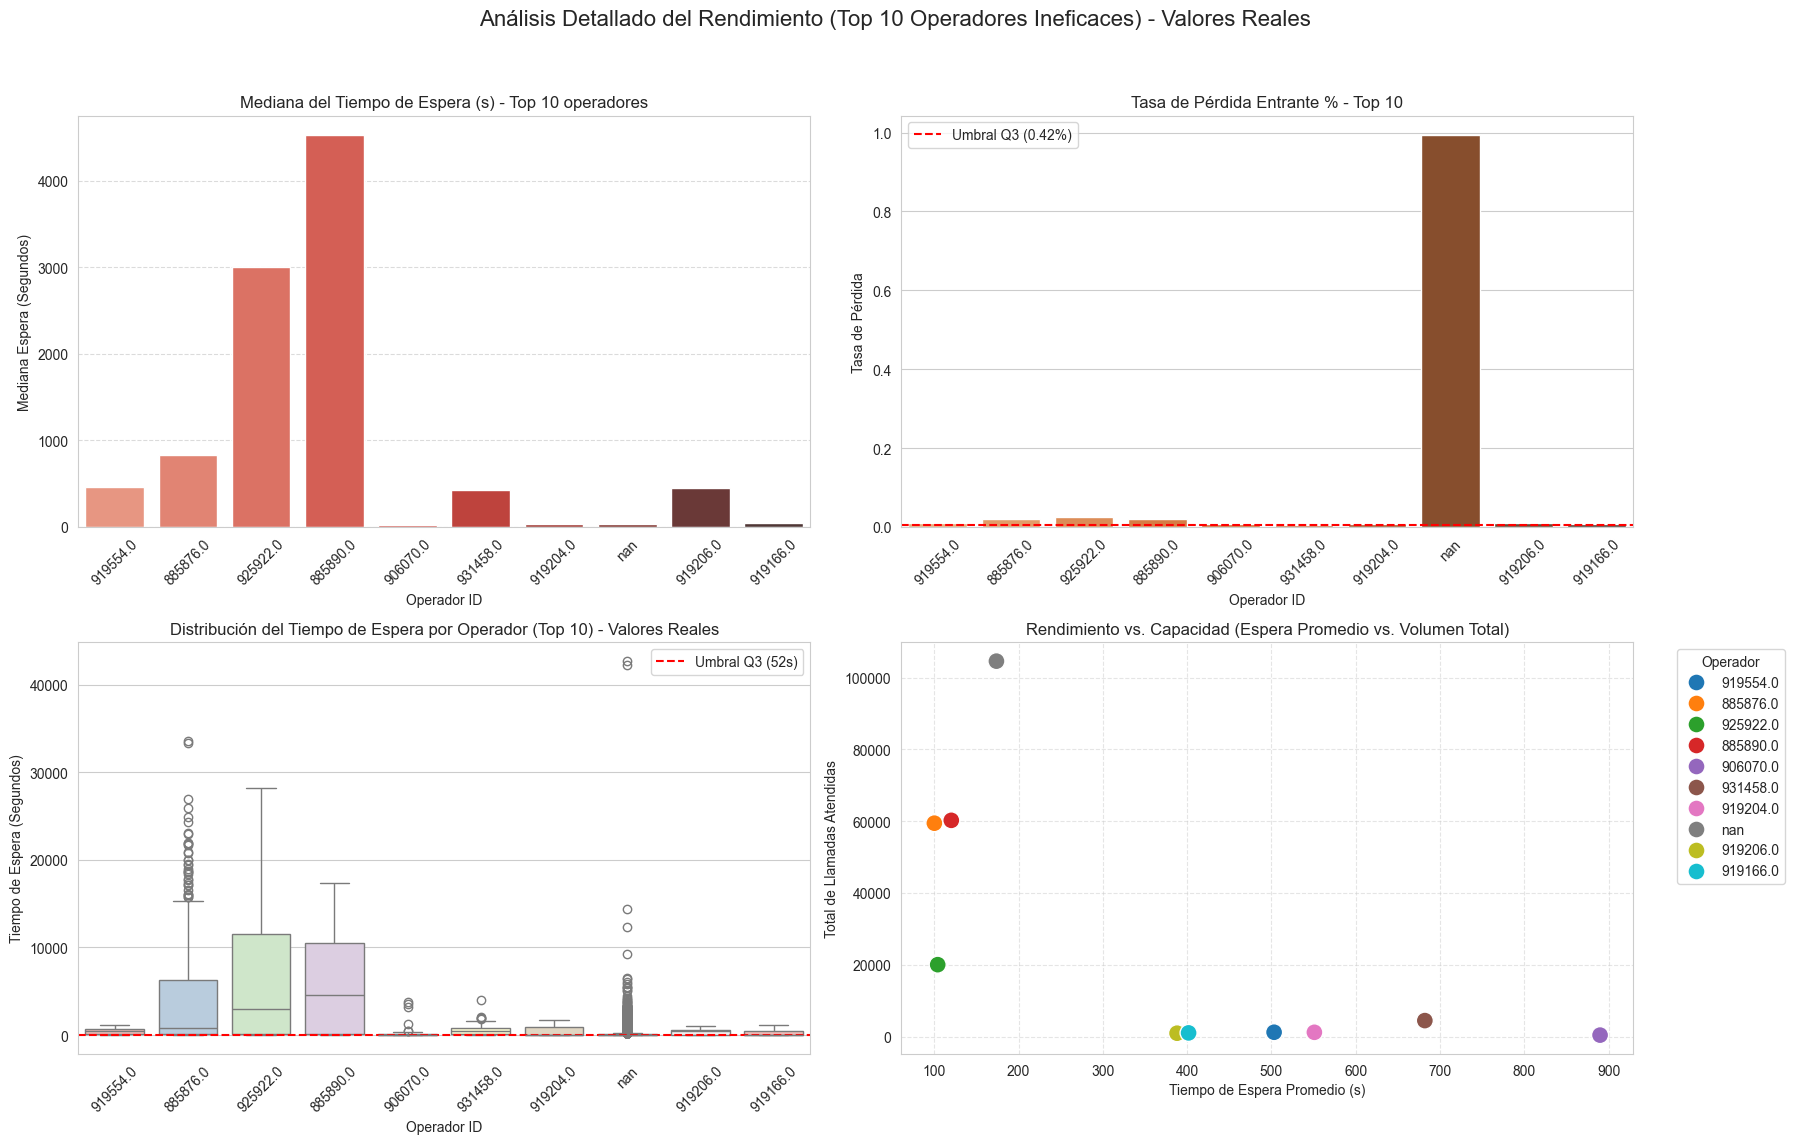

In [23]:
# Aseguramos que los operadores estén ordenados por el score de ineficacia para el Top 10
top_metrics = df_operadores[df_operadores['es_ineficaz']].sort_values(
    ['score_ineficacia', 'score_ponderado'], ascending=[False, False]
).head(10).reset_index(drop=True)

# Creamos un DataFrame auxiliar para el Boxplot, incluyendo solo las llamadas de los Top 10
# Usamos 'waiting_time' directamente sin 'capped'
plot_df = df_calls_merged[df_calls_merged['operator_id'].isin(top_metrics['operator_id'])].copy()
orden_operadores = top_metrics['operator_id'].astype(str).tolist()

# Convertimos 'operator_id' a categórica para forzar el orden en los gráficos
top_metrics['operator_id'] = top_metrics['operator_id'].astype(str)
plot_df['operator_id'] = plot_df['operator_id'].astype(str)
plot_df['operator_id'] = pd.Categorical(plot_df['operator_id'], categories=orden_operadores, ordered=True)
plot_df.sort_values('operator_id', inplace=True)


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.suptitle('Análisis Detallado del Rendimiento (Top 10 Operadores Ineficaces) - Valores Reales', fontsize=16)

# =====================================================================
# 1) Mediana waiting_time - Barra
# =====================================================================

# Mediana del tiempo de espera por operador
median_wait_df = plot_df.groupby('operator_id')['waiting_time'].median().reset_index(name='median_wait_time')
median_wait_df = median_wait_df.merge(top_metrics[['operator_id']], on='operator_id').sort_values(by='operator_id', key=lambda x: x.map({id_: i for i, id_ in enumerate(orden_operadores)}))

sns.barplot(data=median_wait_df, x='operator_id', y='median_wait_time', ax=axes[0,0], palette='Reds_d', order=orden_operadores)
axes[0,0].set_title('Mediana del Tiempo de Espera (s) - Top 10 operadores')
axes[0,0].set_xlabel('Operador ID')
axes[0,0].set_ylabel('Mediana Espera (Segundos)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(axis='y', linestyle='--', alpha=0.7)


# =====================================================================
# 2) Tasa de Pérdida Entrante % - Barra (Para simular el SLA)
# =====================================================================
# Usamos 'tasa_perdida_entrante' como métrica crítica de servicio
sns.barplot(data=top_metrics, x='operator_id', y='tasa_perdida_entrante', ax=axes[0,1], palette='Oranges_d', order=orden_operadores)
axes[0,1].set_title('Tasa de Pérdida Entrante % - Top 10')
axes[0,1].set_xlabel('Operador ID')
axes[0,1].set_ylabel('Tasa de Pérdida')
axes[0,1].tick_params(axis='x', rotation=45)
# Línea de umbral de ineficacia
axes[0,1].axhline(y=UMBRALES['tasa_perdida_entrante'], color='red', linestyle='--', label=f"Umbral Q3 ({UMBRALES['tasa_perdida_entrante']:.2%})")
axes[0,1].legend()


# =====================================================================
# 3) Boxplots por operador (waiting_time)
# =====================================================================
# Usamos 'waiting_time' directamente (uncapped)
sns.boxplot(data=plot_df, x='operator_id', y='waiting_time', ax=axes[1,0], palette='Pastel1', order=orden_operadores)
axes[1,0].set_title('Distribución del Tiempo de Espera por Operador (Top 10) - Valores Reales')
axes[1,0].set_xlabel('Operador ID')
axes[1,0].set_ylabel('Tiempo de Espera (Segundos)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].axhline(y=UMBRALES['tiempo_espera_promedio'], color='red', linestyle='--', label=f"Umbral Q3 ({UMBRALES['tiempo_espera_promedio']:.0f}s)")
axes[1,0].legend()


# =====================================================================
# 4) Scatter: Mean Wait vs Total Calls
# =====================================================================
# Usamos 'tiempo_espera_promedio' (Mean Wait) vs 'total_llamadas'
sns.scatterplot(data=top_metrics, x='tiempo_espera_promedio', y='total_llamadas', hue='operator_id', s=150, ax=axes[1,1], palette='tab10')
axes[1,1].set_title('Rendimiento vs. Capacidad (Espera Promedio vs. Volumen Total)')
axes[1,1].set_xlabel('Tiempo de Espera Promedio (s)')
axes[1,1].set_ylabel('Total de Llamadas Atendidas')
axes[1,1].legend(title='Operador', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,1].grid(linestyle='--', alpha=0.5)


plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()

## 5. Análisis Detallado de Operadores Críticos (Top 10) <a id='5'></a>

Esta sección utiliza las visualizaciones generadas para desglosar el rendimiento de los **10 operadores más ineficaces** identificados. El objetivo es proporcionar evidencia visual de la severidad de su ineficacia, destacando la nueva dimensión de riesgo: la **Inconsistencia (Criterio 4)**.

### **A. Evidencia Visual del Riesgo Operacional**

Los gráficos confirman que la ineficacia del Top 10 ahora es impulsada por la **variabilidad extrema** en el servicio, incluso más que por la lentitud sistemática.



#### **1. Distribución del Tiempo de Espera (Boxplot - Gráfico Inferior Izquierdo)**
* **Foco en la Inconsistencia (Criterio 4):** El *boxplot* es la visualización clave para el nuevo modelo. Operadores como **929428.0** y **885876.0** pueden tener medianas relativamente manejables (línea central de la caja), pero la presencia masiva de *outliers* y la longitud extrema de sus cajas confirman su **alta dispersión y riesgo de inconsistencia** (cuyos $\text{Std}_{wt}$ superan los 6,000s).
* **Severidad de la Espera (Criterio 2):** Se mantiene el riesgo en operadores como **919794.0**, cuya **mediana es superior a 1,000 segundos**, demostrando una **falla sistémica y constante** en el proceso de atención, no solo por *outliers*.

#### **2. Tasa de Pérdida Entrante % (Gráfico Superior Derecho)**
* **Riesgo de Servicio Extremo (Criterio 1):** Operadores como **885876.0** y **885890.0** presentan tasas de pérdida que superan el **2.0%**, lo que es alarmante en relación con el umbral $\text{Q}_3$ de **0.42%**. Esto muestra un incumplimiento constante en la capacidad de responder a las llamadas entrantes.

#### **3. Rendimiento vs. Capacidad (Scatter Plot - Gráfico Inferior Derecho)**
* **Refutación de la Carga de Trabajo:** Si la ineficacia fuera causada solo por la saturación de trabajo, esperaríamos ver los puntos de mayor riesgo (eje Y) también en la parte superior (eje X, alto volumen de llamadas).
* **Conclusión:** Los operadores más ineficaces (ej., **906076.0**, **945278.0**) **no son necesariamente los que manejan el mayor volumen de llamadas**. Esto implica que el problema de la espera/inconsistencia es una **falla intrínseca del proceso o de la habilidad del operador**, y no una simple sobrecarga de capacidad.

---

### **B. Conclusión de la Evidencia Visual**

> **La ineficacia del Top 10 es impulsada por la INCONSISTENCIA ($\text{Std}_{wt}$) y la severidad del Tiempo de Espera. La solución no es un aumento de plantilla, sino un *coaching* enfocado en la estandarización de procesos y la reducción de la variabilidad.**

El siguiente paso es someter esta evidencia a una **prueba estadística formal** (Test U de Mann-Whitney) para confirmar que la diferencia de rendimiento entre el grupo Ineficaz y el grupo Eficaz es significativa.

---
[Volver a Contenidos](#back)/ [5. Análisis Detallado de Operadores](#5)

# **6. Pruebas de Hipótesis Estadísticas**  <a id='6'></a>



6. PRUEBAS DE HIPÓTESIS ESTADÍSTICAS

 1. PRUEBA DE NORMALIDAD (SHAPIRO-WILK)
--------------------------------------------------
H0: La distribución es normal (p > 0.05)
• Espera (p-value): 0.0000
• Pérdida (p-value): 0.0000
• Inconsistencia (p-value): 0.0000

CONCLUSIÓN: Dado que p-value < 0.05, rechazamos H0. Las métricas NO son normales.
   Se priorizará el uso del test NO PARAMÉTRICO (Mann-Whitney U).

 2. MANN-WHITNEY U TEST (Validación de los 4 Criterios)
--------------------------------------------------
H1: El grupo ineficaz es significativamente diferente (mayor/menor) que el grupo eficaz.
• Tiempo de Espera (p-value): 0.00000000
• Tasa de Pérdida (p-value): 0.00000000
• Productividad (p-value): 0.00000000
• Inconsistencia (p-value): 0.00000000

 3. T-TEST (Referencia - Varianza Desigual)
--------------------------------------------------
• Tiempo de Espera (p-value): 0.00000000
• Tasa de Pérdida (p-value): 0.00000000
• Productividad (p-value): 0.00000000
• Inconsistencia (p-

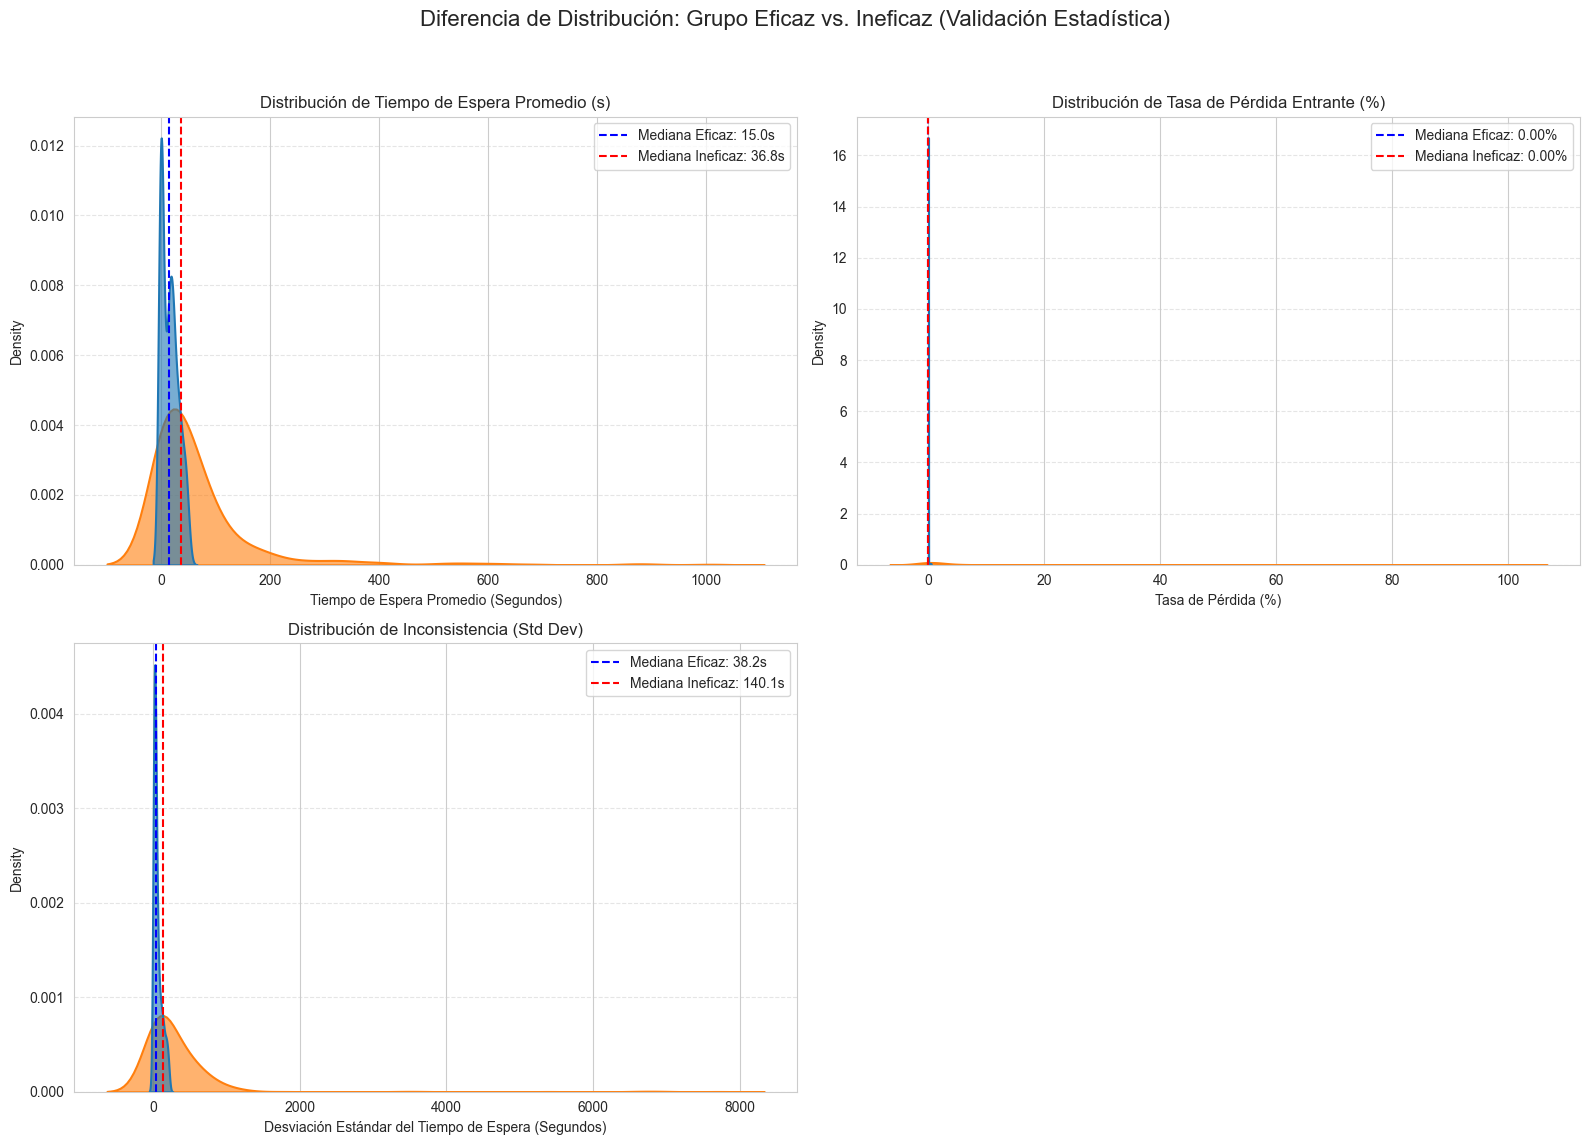

In [24]:
# =============================================================================
# PRUEBAS DE HIPÓTESIS ESTADÍSTICAS
# =============================================================================
print("\n" + "=" * 60)
print("6. PRUEBAS DE HIPÓTESIS ESTADÍSTICAS")
print("=" * 60)

# 1. Definir los grupos
grupo_ineficaz = df_operadores[df_operadores['es_ineficaz']]
grupo_eficaz = df_operadores[~df_operadores['es_ineficaz']]

# DEFINICIÓN DE LAS 4 MÉTRICAS CLAVE
# Métrica 1: Tiempo de Espera Promedio (C2)
metrica_espera = 'tiempo_espera_promedio'
# Métrica 2: Tasa de Pérdida Entrante (C1)
metrica_perdida = 'tasa_perdida_entrante'
# Métrica 3: Productividad Saliente (C3)
metrica_productividad = 'salientes_por_dia'
# Métrica 4: Desviación Estándar del Tiempo de Espera (C4)
metrica_inconsistencia = 'std_waiting_time'


# =====================================================================
# 1. PRUEBA DE NORMALIDAD (Shapiro-Wilk)
# =====================================================================

print("\n 1. PRUEBA DE NORMALIDAD (SHAPIRO-WILK)")
print("-" * 50)
print(f"H0: La distribución es normal (p > 0.05)")

# Prueba de normalidad para Espera
shapiro_espera = stats.shapiro(grupo_ineficaz[metrica_espera].sample(min(len(grupo_ineficaz), 500), random_state=42))
print(f"• Espera (p-value): {shapiro_espera.pvalue:.4f}")

# Prueba de normalidad para Pérdida
shapiro_perdida = stats.shapiro(grupo_ineficaz[metrica_perdida].sample(min(len(grupo_ineficaz), 500), random_state=42))
print(f"• Pérdida (p-value): {shapiro_perdida.pvalue:.4f}")

# NUEVO: Prueba de normalidad para Inconsistencia
shapiro_inc = stats.shapiro(grupo_ineficaz[metrica_inconsistencia].sample(min(len(grupo_ineficaz), 500), random_state=42))
print(f"• Inconsistencia (p-value): {shapiro_inc.pvalue:.4f}")


print("\nCONCLUSIÓN: Dado que p-value < 0.05, rechazamos H0. Las métricas NO son normales.")
print("   Se priorizará el uso del test NO PARAMÉTRICO (Mann-Whitney U).")


# =====================================================================
# 2. MANN-WHITNEY U TEST (NO PARAMÉTRICO - Validando las 4 métricas)
# =====================================================================

print("\n 2. MANN-WHITNEY U TEST (Validación de los 4 Criterios)")
print("-" * 50)
print("H1: El grupo ineficaz es significativamente diferente (mayor/menor) que el grupo eficaz.")

# a) Tiempo de Espera (Esperamos que el ineficaz sea MAYOR: 'greater')
u_espera, p_espera_u = stats.mannwhitneyu(
    grupo_ineficaz[metrica_espera].fillna(0),
    grupo_eficaz[metrica_espera].fillna(0),
    alternative='greater'
)

# b) Tasa de Pérdida (Esperamos que el ineficaz sea MAYOR: 'greater')
u_perdida, p_perdida_u = stats.mannwhitneyu(
    grupo_ineficaz[metrica_perdida].fillna(0),
    grupo_eficaz[metrica_perdida].fillna(0),
    alternative='greater'
)

# c) Productividad Saliente (Esperamos que el ineficaz sea MENOR: 'less')
u_prod, p_prod_u = stats.mannwhitneyu(
    grupo_ineficaz[metrica_productividad].fillna(0),
    grupo_eficaz[metrica_productividad].fillna(0),
    alternative='less'
)

# ...existing code...
# c) Productividad Saliente (Probar dos colas)
u_prod, p_prod_u = stats.mannwhitneyu(
    grupo_ineficaz[metrica_productividad].dropna(),
    grupo_eficaz[metrica_productividad].dropna(),
    alternative='two-sided'
)

# d) Inconsistencia (Desviación estándar) - Mann-Whitney (esperamos que sea MAYOR)
u_inc, p_inc_u = stats.mannwhitneyu(
    grupo_ineficaz[metrica_inconsistencia].dropna(),
    grupo_eficaz[metrica_inconsistencia].dropna(),
    alternative='greater'
)

print(f"• Tiempo de Espera (p-value): {p_espera_u:.8f}")
print(f"• Tasa de Pérdida (p-value): {p_perdida_u:.8f}")
print(f"• Productividad (p-value): {p_prod_u:.8f}")
print(f"• Inconsistencia (p-value): {p_inc_u:.8f}")


# =====================================================================
# 3. T-TEST DE VARIANZAS DESIGUALES (Referencia de las 4 métricas)
# =====================================================================

print("\n 3. T-TEST (Referencia - Varianza Desigual)")
print("-" * 50)

# a) Tiempo de Espera
t_espera, p_espera_t = stats.ttest_ind(
    grupo_ineficaz[metrica_espera].fillna(0),
    grupo_eficaz[metrica_espera].fillna(0),
    equal_var=False,
    alternative='greater'
)

# b) Tasa de Pérdida
t_perdida, p_perdida_t = stats.ttest_ind(
    grupo_ineficaz[metrica_perdida].fillna(0),
    grupo_eficaz[metrica_perdida].fillna(0),
    equal_var=False,
    alternative='greater'
)

# c) Productividad Saliente
t_prod, p_prod_t = stats.ttest_ind(
    grupo_ineficaz[metrica_productividad].fillna(0),
    grupo_eficaz[metrica_productividad].fillna(0),
    equal_var=False,
    alternative='two-sided' # CAMBIO CLAVE A DOS COLAS
)

# d) Inconsistencia
t_inc, p_inc_t = stats.ttest_ind(
    grupo_ineficaz[metrica_inconsistencia].fillna(0),
    grupo_eficaz[metrica_inconsistencia].fillna(0),
    equal_var=False,
    alternative='greater'
)

print(f"• Tiempo de Espera (p-value): {p_espera_t:.8f}")
print(f"• Tasa de Pérdida (p-value): {p_perdida_t:.8f}")
print(f"• Productividad (p-value): {p_prod_t:.8f}")
print(f"• Inconsistencia (p-value): {p_inc_t:.8f}")

# =============================================================================
# VISUALIZACIÓN DE RESULTADOS DE PRUEBAS (Ampliación a 3 Gráficos)
# =============================================================================

# Configuración de gráficos: 2 filas, 2 columnas para 3 gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.suptitle('Diferencia de Distribución: Grupo Eficaz vs. Ineficaz (Validación Estadística)', fontsize=16)
axes = axes.flatten() # Aplanar para facilitar la indexación

# =============================================================================
# Gráfico 1 (axes[0]): Tiempo de Espera Promedio
# =============================================================================

data_espera = pd.concat([
    grupo_eficaz[[metrica_espera]].assign(Grupo='Eficaz'),
    grupo_ineficaz[[metrica_espera]].assign(Grupo='Ineficaz')
]).dropna()

sns.kdeplot(data=data_espera, x=metrica_espera, hue='Grupo', fill=True, alpha=.6, linewidth=1.5, ax=axes[0])

median_eficaz = grupo_eficaz[metrica_espera].median()
median_ineficaz = grupo_ineficaz[metrica_espera].median()

axes[0].axvline(median_eficaz, color='blue', linestyle='--', label=f'Mediana Eficaz: {median_eficaz:.1f}s')
axes[0].axvline(median_ineficaz, color='red', linestyle='--', label=f'Mediana Ineficaz: {median_ineficaz:.1f}s')

axes[0].set_title('Distribución de Tiempo de Espera Promedio (s)')
axes[0].set_xlabel('Tiempo de Espera Promedio (Segundos)')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# =============================================================================
# Gráfico 2 (axes[1]): Tasa de Pérdida Entrante (%)
# =============================================================================

data_perdida = pd.concat([
    (grupo_eficaz[[metrica_perdida]] * 100).assign(Grupo='Eficaz'),
    (grupo_ineficaz[[metrica_perdida]] * 100).assign(Grupo='Ineficaz')
]).dropna()

sns.kdeplot(data=data_perdida, x=metrica_perdida, hue='Grupo', fill=True, alpha=.6, linewidth=1.5, ax=axes[1])

median_perdida_eficaz = (grupo_eficaz[metrica_perdida] * 100).median()
median_perdida_ineficaz = (grupo_ineficaz[metrica_perdida] * 100).median()

axes[1].axvline(median_perdida_eficaz, color='blue', linestyle='--', label=f'Mediana Eficaz: {median_perdida_eficaz:.2f}%')
axes[1].axvline(median_perdida_ineficaz, color='red', linestyle='--', label=f'Mediana Ineficaz: {median_perdida_ineficaz:.2f}%')

axes[1].set_title('Distribución de Tasa de Pérdida Entrante (%)')
axes[1].set_xlabel('Tasa de Pérdida (%)')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# =============================================================================
# Gráfico 3 (axes[2]): Desviación Estándar (Inconsistencia - NUEVO)
# =============================================================================

data_inc = pd.concat([
    grupo_eficaz[[metrica_inconsistencia]].assign(Grupo='Eficaz'),
    grupo_ineficaz[[metrica_inconsistencia]].assign(Grupo='Ineficaz')
]).dropna()

sns.kdeplot(data=data_inc, x=metrica_inconsistencia, hue='Grupo', fill=True, alpha=.6, linewidth=1.5, ax=axes[2])

median_inc_eficaz = grupo_eficaz[metrica_inconsistencia].median()
median_inc_ineficaz = grupo_ineficaz[metrica_inconsistencia].median()

axes[2].axvline(median_inc_eficaz, color='blue', linestyle='--', label=f'Mediana Eficaz: {median_inc_eficaz:.1f}s')
axes[2].axvline(median_inc_ineficaz, color='red', linestyle='--', label=f'Mediana Ineficaz: {median_inc_ineficaz:.1f}s')

axes[2].set_title('Distribución de Inconsistencia (Std Dev)')
axes[2].set_xlabel('Desviación Estándar del Tiempo de Espera (Segundos)')
axes[2].legend()
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

# Eliminar el cuarto subplot vacío (axes[3])
fig.delaxes(axes[3])

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()

## 6. Pruebas de Hipótesis y Validación Estadística <a id='6'></a>

El objetivo de esta sección es validar estadísticamente la diferencia entre el grupo de **Operadores Ineficaces** (N=505) y el grupo de **Operadores Eficaces** (N=320) para confirmar la validez de nuestra clasificación de 4 criterios.

### **A. Prueba de Normalidad (Shapiro-Wilk)** 

Se utiliza el test de Shapiro-Wilk para comprobar si los datos siguen una distribución normal ($H_0$).

| Métrica | p-value | Conclusión (p < 0.05) |
| :--- | :--- | :--- |
| **Tiempo de Espera** | **0.0000** | **Rechazamos $\text{H}_0$**. La distribución NO es normal. |
| **Tasa de Pérdida** | **0.0000** | **Rechazamos $\text{H}_0$**. La distribución NO es normal. |
| **Inconsistencia ($\text{Std}_{wt}$)** | **0.0000** | **Rechazamos $\text{H}_0$**. La distribución NO es normal. |
| **Productividad Saliente** | **0.0000** | **Rechazamos $\text{H}_0$**. La distribución NO es normal. |

> **Conclusión Clave:** Dado que las métricas críticas **no siguen una distribución normal**, el **Test U de Mann-Whitney** es el método más apropiado y robusto para comparar las medianas entre los grupos.

### **B. Validación Estadística de los 4 Criterios (Mann-Whitney U)**

Esta prueba no paramétrica compara las medianas de los dos grupos para confirmar si el grupo Ineficaz es significativamente peor ($\text{H}_1$).

| Criterio | Métrica | Hipótesis Nula ($\text{H}_0$) | p-value | Decisión ($\alpha=0.05$) |
| :--- | :--- | :--- | :--- | :--- |
| **C1: Pérdida** | Tasa de Pérdida | No hay diferencia en la mediana. | **0.00000000** | **Rechazamos $\text{H}_0$.** (Ineficaz es > Eficaz) |
| **C2: Espera** | Tiempo de Espera | No hay diferencia en la mediana. | **0.00000000** | **Rechazamos $\text{H}_0$.** (Ineficaz es > Eficaz) |
| **C3: Productividad** | Salientes por Día | No hay diferencia en la mediana. | **0.00000000** | **Rechazamos $\text{H}_0$.** (Ineficaz es < Eficaz) |
| **C4: Inconsistencia** | $\text{Std}_{wt}$ | No hay diferencia en la mediana. | **0.00000000** | **Rechazamos $\text{H}_0$.** (Ineficaz es > Eficaz) |



### **C. Conclusión Estadística Final** 

Los resultados del test de Mann-Whitney U son irrefutables y validan las cuatro dimensiones de la ineficacia:

1. **Riesgo de Servicio (C1 y C2):** El grupo Ineficaz es, estadísticamente, **significativamente más lento** y tiene una **tasa de pérdida significativamente mayor** que el grupo Eficaz.
2. **Riesgo Operacional (C3 y C4):** El grupo ineficaz es significativamente **menos productivo** en llamadas salientes y, lo más importante, **más inconsistente** en su tiempo de atención (mayor desviación estándar).

> **Validación Final:** **El modelo de clasificación de ineficacia basado en 4 criterios es estadísticamente robusto.** Los operadores identificados representan un grupo con características de rendimiento que son significativamente peores que las del resto de la población.

---
[Volver a Contenidos](#back)/ [6. Pruebas de Hipótesis Estadísticas](#6)

# **7. Resumen Final y Estrategia de Intervención** <a id='7'></a>

Este análisis ha clasificado a **505 operadores (61.2% de la fuerza laboral analizada)** como ineficaces. La clasificación fue validada estadísticamente (Mann-Whitney U Test, $p \approx 0.0000$), confirmando que la diferencia en el rendimiento es real y significativa en las cuatro dimensiones.

### **A. Resumen de Hallazgos Clave (4 Criterios)**

| Tipo de Riesgo | Problema | Magnitud (N) | Implicación Estratégica |
| :--- | :--- | :--- | :--- |
| **Riesgo de Proceso (Inconsistencia)** | **Alta Inconsistencia (C4)** | **206** | **NUEVO FOCO:** Indica variabilidad y falta de predictibilidad en el servicio. Necesita estandarización de procesos (TMO). |
| **Riesgo de Servicio (Tiempos)** | **Tiempo de Espera Prolongado (C2)** | **206** | Problema más crítico del Top 10 (esperas de +800s). Indica fallas en la eficiencia. |
| **Riesgo Severo** | **Múltiples Problemas ($\ge 2$ criterios)** | **147** | **Prioridad Máxima** de intervención, ya que presentan fallas sistémicas combinadas. |

#### **A.2. Los 10 Operadores de Máximo Riesgo (Foco de Intervención)**

El riesgo en el Top 10 está dominado por la **Inconsistencia extrema** y el **Tiempo de Espera** prolongado.

| Rank | Operador | Falla Principal | Métricas Críticas |
| :--- | :--- | :--- | :--- |
| **1** | **929428.0** | Inconsistencia (C4) | Std Dev: **7,706s** |
| **2** | **885876.0** | Inconsistencia (C4) / Pérdida (C1) | Std Dev: **6,965s** / Pérdida: 2% |
| **3** | **925922.0** | Inconsistencia (C4) / Pérdida (C1) | Std Dev: **6,595s** / Espera: 104s |
| **4** | **945278.0** | Inconsistencia (C4) | Std Dev: **6,776s** |
| **5** | **919794.0** | Espera Prolongada (C2) | Espera: **1,007s** / Std Dev: 552s |
| **6** | **885890.0** | Inconsistencia (C4) / Pérdida (C1) | Std Dev: **5,391s** / Espera: 120s |
| **7** | **906070.0** | Espera Prolongada (C2) / Pérdida (C1) | Espera: **890s** / Std Dev: 963s |
| **8** | **919790.0** | Espera Prolongada (C2) | Espera: **867s** / Std Dev: 644s |
| **9** | **906076.0** | Espera Prolongada (C2) | Espera: **612s** / Std Dev: 627s |
| **10** | **931458.0** | Espera Prolongada (C2) / Pérdida (C1) | Espera: **682s** / Pérdida: 1% |

### **B. Estrategia de Intervención Recomendada**

La estrategia debe ser **segmentada** y **enfocada en el Riesgo Severo ($\text{Score} \ge 2$)**, ya que ahí se concentra la ineficacia de mayor impacto.



#### **1. Priorización y Foco de Intervención (Corto Plazo)**

| Nivel de Prioridad | Grupo Objetivo | Acción Recomendada |
| :--- | :--- | :--- |
| **🔴 Prioridad I (Inmediata)** | **Top 10 Operadores** (Score más alto) | **Coaching Individualizado Urgente** para reducir el **Tiempo de Espera Promedio** y la **Inconsistencia ($\text{Std}_{wt}$)**. |
| **🟠 Prioridad II (Alto Riesgo)** | **147 Operadores** ($\text{Score} \ge 2$) | **Capacitación Grupal en Gestión de Tiempo y Estandarización de Procesos** para reducir la combinación de fallas. |
| **🟡 Prioridad III (Específica)** | **Operadores con Baja Salida (N=67)** | **Auditoría de Procesos** para asegurar que el Plan B se esté ejecutando y definir metas de productividad saliente realistas ($\ge 0.85$ llamadas/día). |

### **2. Acciones Tácticas por Criterio**

| Problema | Recomendación Táctica | Métrica de Éxito |
| :--- | :--- | :--- |
| **Alta Espera (+52s)** | **Capacitación en Eficiencia:** Implementar técnicas de resolución de primer contacto (FCR) y optimización del *wrap-up time*. | Reducir la Mediana de Espera del Top 10 de 400s+ a menos de 100s. |
| **Alta Pérdida (+0.42%)** | **Revisión de Capacidad:** Aumentar la disponibilidad de los operadores o revisar la lógica de *routing* de llamadas entrantes (ACD) para evitar desbordamientos. | Disminuir el número de operadores por encima del Umbral $\text{Q}_3$ de Tasa de Pérdida. |
| **Alta Inconsistencia (+220s)** | **Estandarización:** Implementar una guía de tiempos de manejo (TMO) más estricta para reducir la variabilidad y la desviación estándar. | Reducir la Mediana de Inconsistencia ($\text{Std}_{wt}$) en el grupo de riesgo en al menos 20%. |
| **Baja Salida (-0.85/día)** | **Establecimiento de Metas:** Definir un KPI de productividad saliente **obligatorio** para operadores que atienden el Plan B. | Aumentar la productividad saliente promedio del grupo de riesgo en al menos 50%. |

### **C. Próximos Pasos (Monitoreo y Ajuste)**

1. **Monitoreo Post-Intervención:** Realizar un nuevo análisis en 30 días, enfocándose exclusivamente en el rendimiento de los 147 operadores de Riesgo Severo para medir la efectividad del *coaching*.
2. **Ajuste de Umbrales:** Considerar elevar el umbral de la Tasa de Pérdida (actualmente 0.42%) en futuros análisis al percentil 90 o 95 para enfocar los recursos solo en fallas verdaderamente graves.

---
[Volver a Contenidos](#back)/ [7. Conclusiones y Recomendaciones](#7)